# Semantic + Spatial VLM Comparison

This notebook evaluates the harder **semantic + spatial** dataset built from the recorded milk-carton scenes.

## Models compared
- `text_only_clip`
- `image_text_clip`
- `text_only_siglip`
- `image_text_siglip`

## Goal
Measure whether adding the image helps once language shortcuts are reduced by spatial and semantic prompts.


In [1]:
# Optional install cell if needed.
# import sys
# !{sys.executable} -m pip install transformers accelerate sentencepiece protobuf==3.20.3


In [2]:
from pathlib import Path
import gc
import json
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoModel, AutoProcessor

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [3]:
PROJECT_ROOT = Path('/home/gyanig/catkin_ws/src/tabletop_workspace_opt')
DATA_ROOT = PROJECT_ROOT / 'data' / 'milk_candidate_cls'
SAMPLES_PATH = DATA_ROOT / 'candidate_samples_semantic_spatial.jsonl'
SPLIT_ROOT = DATA_ROOT / 'splits'
SPLIT_ROOT.mkdir(parents=True, exist_ok=True)

CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'
SIGLIP_MODEL_NAME = 'google/siglip-base-patch16-224'
BATCH_SIZE = 4
EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

assert SAMPLES_PATH.exists(), SAMPLES_PATH


In [4]:
def load_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

df = pd.DataFrame(load_jsonl(SAMPLES_PATH))
df.head(2)


,sample_id,episode_id,scene_id,view_id,image_path,instruction,correct_candidate_id,label,task_type,scene_notes,episode_notes,slot_assignment,candidate_id,object_short,object_name,grasp_type,grasp_description,task_suitability,candidate_text,candidate_text_reduced
0,milk_scene_01_top__semsp_001__whole_top,milk_scene_01_top__semsp_001,milk_scene_01_top,top,images/milk_scene_01_top.png,Pick the carton on the left.,whole_top,1,pickup,fixed layout v1; synthetic_semantic_spatial_pr...,spatial_prompt,"{'left': 'whole_milk', 'center': 'oat_milk', '...",whole_top,whole,whole_milk,top,top grasp,pickup,Object: whole_milk. Grasp: top grasp. Task sui...,Candidate grasp type: top grasp.
1,milk_scene_01_top__semsp_001__whole_side,milk_scene_01_top__semsp_001,milk_scene_01_top,top,images/milk_scene_01_top.png,Pick the carton on the left.,whole_top,0,pickup,fixed layout v1; synthetic_semantic_spatial_pr...,spatial_prompt,"{'left': 'whole_milk', 'center': 'oat_milk', '...",whole_side,whole,whole_milk,side,side grasp,pour,Object: whole_milk. Grasp: side grasp. Task su...,Candidate grasp type: side grasp.


In [5]:
def base_scene_id(scene_id: str) -> str:
    for suffix in ('_top', '_side', '_lean'):
        if scene_id.endswith(suffix):
            return scene_id[:-len(suffix)]
    return scene_id

df['base_scene_id'] = df['scene_id'].map(base_scene_id)
df['text_input'] = df.apply(
    lambda row: f"Instruction: {row['instruction']}\nCandidate: {row['candidate_text']}", axis=1
)
df['text_input_reduced'] = df.apply(
    lambda row: f"Instruction: {row['instruction']}\nCandidate: {row.get('candidate_text_reduced', row['candidate_text'])}", axis=1
)

print('rows:', len(df))
print('episodes:', df['episode_id'].nunique())
print('base scenes:', sorted(df['base_scene_id'].unique()))
print(df[['instruction', 'correct_candidate_id', 'episode_notes']].head(8))


rows: 2700
episodes: 450
base scenes: ['milk_scene_01', 'milk_scene_02', 'milk_scene_03', 'milk_scene_04', 'milk_scene_05', 'scene_04']
                    instruction correct_candidate_id   episode_notes
0  Pick the carton on the left.            whole_top  spatial_prompt
1  Pick the carton on the left.            whole_top  spatial_prompt
2  Pick the carton on the left.            whole_top  spatial_prompt
3  Pick the carton on the left.            whole_top  spatial_prompt
4  Pick the carton on the left.            whole_top  spatial_prompt
5  Pick the carton on the left.            whole_top  spatial_prompt
6      Pick up the left carton.            whole_top  spatial_prompt
7      Pick up the left carton.            whole_top  spatial_prompt


In [6]:
base_scenes = sorted(df['base_scene_id'].unique())
assert len(base_scenes) >= 2, 'Need at least two base scenes for a scene split.'

val_scene_count = 2 if len(base_scenes) >= 4 else 1
train_scenes = base_scenes[:-val_scene_count]
val_scenes = base_scenes[-val_scene_count:]

train_df = df[df['base_scene_id'].isin(train_scenes)].reset_index(drop=True)
val_df = df[df['base_scene_id'].isin(val_scenes)].reset_index(drop=True)

print('train scenes:', train_scenes)
print('val scenes  :', val_scenes)
print('train rows   :', len(train_df))
print('val rows     :', len(val_df))
print('train episodes:', train_df['episode_id'].nunique())
print('val episodes  :', val_df['episode_id'].nunique())


train scenes: ['milk_scene_01', 'milk_scene_02', 'milk_scene_03', 'milk_scene_04']
val scenes  : ['milk_scene_05', 'scene_04']
train rows   : 1980
val rows     : 720
train episodes: 330
val episodes  : 120


In [7]:
def build_episode_records(frame: pd.DataFrame, text_column='text_input'):
    records = []
    grouped = frame.groupby('episode_id', sort=True)
    for episode_id, g in grouped:
        g = g.sort_values('candidate_id').reset_index(drop=True)
        assert len(g) == 6, f'{episode_id} has {len(g)} candidates instead of 6'
        pos = g[g['label'] == 1]
        assert len(pos) == 1, f'{episode_id} must have exactly one positive candidate'
        records.append({
            'episode_id': episode_id,
            'scene_id': g.iloc[0]['scene_id'],
            'base_scene_id': g.iloc[0]['base_scene_id'],
            'view_id': g.iloc[0]['view_id'],
            'image_path': g.iloc[0]['image_path'],
            'instruction': g.iloc[0]['instruction'],
            'candidate_ids': g['candidate_id'].tolist(),
            'candidate_texts': g[text_column].tolist(),
            'correct_candidate_id': pos.iloc[0]['candidate_id'],
            'target_index': int(pos.index[0]),
        })
    return records

train_records = build_episode_records(train_df, text_column='text_input')
val_records = build_episode_records(val_df, text_column='text_input')

print('train episodes:', len(train_records))
print('val episodes  :', len(val_records))
train_records[0]


train episodes: 330
val episodes  : 120


{'episode_id': 'milk_scene_01_lean__semsp_031',
 'scene_id': 'milk_scene_01_lean',
 'base_scene_id': 'milk_scene_01',
 'view_id': 'lean',
 'image_path': 'images/milk_scene_01_lean.png',
 'instruction': 'Pick the carton on the left.',
 'candidate_ids': ['oat_side',
  'oat_top',
  'soy_side',
  'soy_top',
  'whole_side',
  'whole_top'],
 'candidate_texts': ['Instruction: Pick the carton on the left.\nCandidate: Object: oat_milk. Grasp: side grasp. Task suitability: pour.',
  'Instruction: Pick the carton on the left.\nCandidate: Object: oat_milk. Grasp: top grasp. Task suitability: pickup.',
  'Instruction: Pick the carton on the left.\nCandidate: Object: soy_milk. Grasp: side grasp. Task suitability: pour.',
  'Instruction: Pick the carton on the left.\nCandidate: Object: soy_milk. Grasp: top grasp. Task suitability: pickup.',
  'Instruction: Pick the carton on the left.\nCandidate: Object: whole_milk. Grasp: side grasp. Task suitability: pour.',
  'Instruction: Pick the carton on the l

In [8]:
class TextOnlyEpisodeDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        return {
            'candidate_texts': rec['candidate_texts'],
            'target_index': rec['target_index'],
        }


class ImageTextEpisodeDataset(Dataset):
    def __init__(self, records, image_root):
        self.records = records
        self.image_root = image_root

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        image = Image.open(self.image_root / rec['image_path']).convert('RGB')
        return {
            'image': image,
            'candidate_texts': rec['candidate_texts'],
            'target_index': rec['target_index'],
        }


In [9]:
def get_image_features(model, pixel_values):
    if hasattr(model, 'get_image_features'):
        return model.get_image_features(pixel_values=pixel_values)
    return model.vision_model(pixel_values=pixel_values).pooler_output


def get_text_features(model, input_ids, attention_mask=None):
    if hasattr(model, 'get_text_features'):
        kwargs = {'input_ids': input_ids}
        if attention_mask is not None:
            kwargs['attention_mask'] = attention_mask
        return model.get_text_features(**kwargs)
    if attention_mask is not None:
        return model.text_model(input_ids=input_ids, attention_mask=attention_mask).pooler_output
    return model.text_model(input_ids=input_ids).pooler_output


def l2_normalize(x):
    return x / x.norm(dim=-1, keepdim=True).clamp_min(1e-6)


class TextOnlyEpisodeRanker(nn.Module):
    def __init__(self, vlm_backbone, embed_dim):
        super().__init__()
        self.vlm_backbone = vlm_backbone
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1),
        )

    def forward(self, input_ids, attention_mask, num_candidates):
        with torch.no_grad():
            text_feat = get_text_features(self.vlm_backbone, input_ids, attention_mask)
            text_feat = l2_normalize(text_feat)
        logits = self.scorer(text_feat).view(-1, num_candidates)
        return logits


class ImageTextEpisodeRanker(nn.Module):
    def __init__(self, vlm_backbone, embed_dim):
        super().__init__()
        self.vlm_backbone = vlm_backbone
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1),
        )

    def forward(self, pixel_values, input_ids, attention_mask, num_candidates):
        batch_size = pixel_values.shape[0]
        with torch.no_grad():
            image_feat = get_image_features(self.vlm_backbone, pixel_values)
            text_feat = get_text_features(self.vlm_backbone, input_ids, attention_mask)
            image_feat = l2_normalize(image_feat)
            text_feat = l2_normalize(text_feat)
        image_feat = image_feat.repeat_interleave(num_candidates, dim=0)
        joint = torch.cat([image_feat, text_feat, image_feat * text_feat], dim=1)
        logits = self.scorer(joint).view(batch_size, num_candidates)
        return logits


In [10]:
def collate_text_only(batch, processor):
    texts = []
    for item in batch:
        texts.extend(item['candidate_texts'])
    text_inputs = processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    out = {
        'input_ids': text_inputs['input_ids'],
        'targets': torch.tensor([item['target_index'] for item in batch], dtype=torch.long),
        'num_candidates': len(batch[0]['candidate_texts']),
    }
    if 'attention_mask' in text_inputs:
        out['attention_mask'] = text_inputs['attention_mask']
    return out


def collate_image_text(batch, processor):
    images = [item['image'] for item in batch]
    texts = []
    for item in batch:
        texts.extend(item['candidate_texts'])
    image_inputs = processor(images=images, return_tensors='pt')
    text_inputs = processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    out = {
        'pixel_values': image_inputs['pixel_values'],
        'input_ids': text_inputs['input_ids'],
        'targets': torch.tensor([item['target_index'] for item in batch], dtype=torch.long),
        'num_candidates': len(batch[0]['candidate_texts']),
    }
    if 'attention_mask' in text_inputs:
        out['attention_mask'] = text_inputs['attention_mask']
    return out


def run_text_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss = 0.0
    n = 0
    correct = 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch.get('attention_mask')
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)
        targets = batch['targets'].to(device)
        logits = model(input_ids, attention_mask, batch['num_candidates'])
        loss = criterion(logits, targets)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        pred = logits.argmax(dim=1)
        correct += int((pred == targets).sum().item())
        n += len(targets)
        total_loss += float(loss.item()) * len(targets)
    return {'loss': total_loss / max(n, 1), 'episode_top1': correct / max(n, 1)}


def run_image_text_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss = 0.0
    n = 0
    correct = 0
    for batch in loader:
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch.get('attention_mask')
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)
        targets = batch['targets'].to(device)
        logits = model(pixel_values, input_ids, attention_mask, batch['num_candidates'])
        loss = criterion(logits, targets)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        pred = logits.argmax(dim=1)
        correct += int((pred == targets).sum().item())
        n += len(targets)
        total_loss += float(loss.item()) * len(targets)
    return {'loss': total_loss / max(n, 1), 'episode_top1': correct / max(n, 1)}


def train_text_only(backbone_name, model_label, train_records, val_records):
    processor = AutoProcessor.from_pretrained(backbone_name)
    backbone = AutoModel.from_pretrained(backbone_name).to(device)
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False

    with torch.no_grad():
        dummy = processor(text=train_records[0]['candidate_texts'][0], return_tensors='pt', padding=True)
        embed_dim = int(
            get_text_features(
                backbone,
                dummy['input_ids'].to(device),
                dummy.get('attention_mask').to(device) if dummy.get('attention_mask') is not None else None,
            ).shape[-1]
        )

    train_ds = TextOnlyEpisodeDataset(train_records)
    val_ds = TextOnlyEpisodeDataset(val_records)
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        collate_fn=lambda batch: collate_text_only(batch, processor),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=lambda batch: collate_text_only(batch, processor),
    )

    model = TextOnlyEpisodeRanker(backbone, embed_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.scorer.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []
    best_val = -1.0
    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_text_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_text_epoch(model, val_loader, criterion, optimizer=None)
        row = {
            'model': model_label,
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_episode_top1': train_metrics['episode_top1'],
            'val_loss': val_metrics['loss'],
            'val_episode_top1': val_metrics['episode_top1'],
        }
        history.append(row)
        print(row)
        best_val = max(best_val, row['val_episode_top1'])

    del model, optimizer, criterion, backbone, processor, train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.DataFrame(history), best_val


def train_image_text(backbone_name, model_label, train_records, val_records):
    processor = AutoProcessor.from_pretrained(backbone_name)
    backbone = AutoModel.from_pretrained(backbone_name).to(device)
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False

    with torch.no_grad():
        dummy_img = Image.open(DATA_ROOT / train_records[0]['image_path']).convert('RGB')
        dummy_text = train_records[0]['candidate_texts'][0]
        dummy = processor(images=dummy_img, text=dummy_text, return_tensors='pt', padding=True)
        embed_dim = int(get_image_features(backbone, dummy['pixel_values'].to(device)).shape[-1])

    train_ds = ImageTextEpisodeDataset(train_records, DATA_ROOT)
    val_ds = ImageTextEpisodeDataset(val_records, DATA_ROOT)
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        collate_fn=lambda batch: collate_image_text(batch, processor),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=lambda batch: collate_image_text(batch, processor),
    )

    model = ImageTextEpisodeRanker(backbone, embed_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.scorer.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []
    best_val = -1.0
    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_image_text_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_image_text_epoch(model, val_loader, criterion, optimizer=None)
        row = {
            'model': model_label,
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_episode_top1': train_metrics['episode_top1'],
            'val_loss': val_metrics['loss'],
            'val_episode_top1': val_metrics['episode_top1'],
        }
        history.append(row)
        print(row)
        best_val = max(best_val, row['val_episode_top1'])

    del model, optimizer, criterion, backbone, processor, train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.DataFrame(history), best_val


## Text-Only CLIP

In [11]:
clip_text_history_df, clip_text_best = train_text_only(
    CLIP_MODEL_NAME,
    'text_only_clip',
    train_records,
    val_records,
)
print('Best text-only CLIP val top1:', clip_text_best)
clip_text_history_df


{'model': 'text_only_clip', 'epoch': 1, 'train_loss': 1.7785261515415076, 'train_episode_top1': 0.27575757575757576, 'val_loss': 1.7507725516955057, 'val_episode_top1': 0.4}
{'model': 'text_only_clip', 'epoch': 2, 'train_loss': 1.704114521633495, 'train_episode_top1': 0.3878787878787879, 'val_loss': 1.6355482339859009, 'val_episode_top1': 0.43333333333333335}
{'model': 'text_only_clip', 'epoch': 3, 'train_loss': 1.5725829268946792, 'train_episode_top1': 0.4696969696969697, 'val_loss': 1.4771462519963583, 'val_episode_top1': 0.4666666666666667}
{'model': 'text_only_clip', 'epoch': 4, 'train_loss': 1.3991648142988031, 'train_episode_top1': 0.5272727272727272, 'val_loss': 1.3227237701416015, 'val_episode_top1': 0.6333333333333333}
{'model': 'text_only_clip', 'epoch': 5, 'train_loss': 1.2534291458852362, 'train_episode_top1': 0.6181818181818182, 'val_loss': 1.165984050432841, 'val_episode_top1': 0.6416666666666667}
{'model': 'text_only_clip', 'epoch': 6, 'train_loss': 1.1270045699495257, '

,model,epoch,train_loss,train_episode_top1,val_loss,val_episode_top1
0,text_only_clip,1,1.778526,0.275758,1.750773,0.400000
1,text_only_clip,2,1.704115,0.387879,1.635548,0.433333
2,text_only_clip,3,1.572583,0.469697,1.477146,0.466667
3,text_only_clip,4,1.399165,0.527273,1.322724,0.633333
4,text_only_clip,5,1.253429,0.618182,1.165984,0.641667
5,text_only_clip,6,1.127005,0.672727,1.038843,0.716667
6,text_only_clip,7,0.998695,0.675758,0.925966,0.716667
7,text_only_clip,8,0.926834,0.706061,0.848871,0.716667
8,text_only_clip,9,0.833612,0.757576,0.766757,0.775000
9,text_only_clip,10,0.754789,0.763636,0.703906,0.800000


## Image + Text CLIP

In [12]:
clip_image_text_history_df, clip_image_text_best = train_image_text(
    CLIP_MODEL_NAME,
    'image_text_clip',
    train_records,
    val_records,
)
print('Best image+text CLIP val top1:', clip_image_text_best)
clip_image_text_history_df


{'model': 'image_text_clip', 'epoch': 1, 'train_loss': 1.7821449915568033, 'train_episode_top1': 0.24848484848484848, 'val_loss': 1.7678134838740032, 'val_episode_top1': 0.3333333333333333}
{'model': 'image_text_clip', 'epoch': 2, 'train_loss': 1.753793438275655, 'train_episode_top1': 0.2787878787878788, 'val_loss': 1.71623055934906, 'val_episode_top1': 0.36666666666666664}
{'model': 'image_text_clip', 'epoch': 3, 'train_loss': 1.6795515132672858, 'train_episode_top1': 0.3393939393939394, 'val_loss': 1.625122618675232, 'val_episode_top1': 0.425}
{'model': 'image_text_clip', 'epoch': 4, 'train_loss': 1.6017131241885099, 'train_episode_top1': 0.37575757575757573, 'val_loss': 1.533570158481598, 'val_episode_top1': 0.38333333333333336}
{'model': 'image_text_clip', 'epoch': 5, 'train_loss': 1.497151460792079, 'train_episode_top1': 0.47878787878787876, 'val_loss': 1.425344208876292, 'val_episode_top1': 0.4666666666666667}
{'model': 'image_text_clip', 'epoch': 6, 'train_loss': 1.3923701091246

,model,epoch,train_loss,train_episode_top1,val_loss,val_episode_top1
0,image_text_clip,1,1.782145,0.248485,1.767813,0.333333
1,image_text_clip,2,1.753793,0.278788,1.716231,0.366667
2,image_text_clip,3,1.679552,0.339394,1.625123,0.425000
3,image_text_clip,4,1.601713,0.375758,1.533570,0.383333
4,image_text_clip,5,1.497151,0.478788,1.425344,0.466667
5,image_text_clip,6,1.392370,0.484848,1.325450,0.625000
6,image_text_clip,7,1.324763,0.503030,1.241209,0.675000
7,image_text_clip,8,1.258018,0.536364,1.169669,0.683333
8,image_text_clip,9,1.190152,0.612121,1.109833,0.683333
9,image_text_clip,10,1.091170,0.630303,1.052169,0.658333


## Text-Only SigLIP

In [13]:
siglip_text_history_df, siglip_text_best = train_text_only(
    SIGLIP_MODEL_NAME,
    'text_only_siglip',
    train_records,
    val_records,
)
print('Best text-only SigLIP val top1:', siglip_text_best)
siglip_text_history_df


{'model': 'text_only_siglip', 'epoch': 1, 'train_loss': 1.7536618839610707, 'train_episode_top1': 0.3181818181818182, 'val_loss': 1.6859692374865214, 'val_episode_top1': 0.425}
{'model': 'text_only_siglip', 'epoch': 2, 'train_loss': 1.5607058756279222, 'train_episode_top1': 0.43333333333333335, 'val_loss': 1.461882750193278, 'val_episode_top1': 0.5}
{'model': 'text_only_siglip', 'epoch': 3, 'train_loss': 1.4116618474324545, 'train_episode_top1': 0.49696969696969695, 'val_loss': 1.3408482988675436, 'val_episode_top1': 0.5333333333333333}
{'model': 'text_only_siglip', 'epoch': 4, 'train_loss': 1.2428372782288175, 'train_episode_top1': 0.5636363636363636, 'val_loss': 1.2673826138178508, 'val_episode_top1': 0.625}
{'model': 'text_only_siglip', 'epoch': 5, 'train_loss': 1.1484613956827106, 'train_episode_top1': 0.6242424242424243, 'val_loss': 1.1514078438282014, 'val_episode_top1': 0.6083333333333333}
{'model': 'text_only_siglip', 'epoch': 6, 'train_loss': 1.0576559529160008, 'train_episode

,model,epoch,train_loss,train_episode_top1,val_loss,val_episode_top1
0,text_only_siglip,1,1.753662,0.318182,1.685969,0.425000
1,text_only_siglip,2,1.560706,0.433333,1.461883,0.500000
2,text_only_siglip,3,1.411662,0.496970,1.340848,0.533333
3,text_only_siglip,4,1.242837,0.563636,1.267383,0.625000
4,text_only_siglip,5,1.148461,0.624242,1.151408,0.608333
5,text_only_siglip,6,1.057656,0.639394,1.050372,0.708333
6,text_only_siglip,7,0.999576,0.666667,0.960550,0.641667
7,text_only_siglip,8,0.978318,0.669697,0.901592,0.733333
8,text_only_siglip,9,0.827204,0.730303,0.836190,0.733333
9,text_only_siglip,10,0.804955,0.736364,0.825061,0.716667


## Image + Text SigLIP

In [14]:
siglip_image_text_history_df, siglip_image_text_best = train_image_text(
    SIGLIP_MODEL_NAME,
    'image_text_siglip',
    train_records,
    val_records,
)
print('Best image+text SigLIP val top1:', siglip_image_text_best)
siglip_image_text_history_df


{'model': 'image_text_siglip', 'epoch': 1, 'train_loss': 1.761088481093898, 'train_episode_top1': 0.30303030303030304, 'val_loss': 1.711270765463511, 'val_episode_top1': 0.4583333333333333}
{'model': 'image_text_siglip', 'epoch': 2, 'train_loss': 1.6268313256177036, 'train_episode_top1': 0.3606060606060606, 'val_loss': 1.5449922204017639, 'val_episode_top1': 0.4583333333333333}
{'model': 'image_text_siglip', 'epoch': 3, 'train_loss': 1.4632653749350346, 'train_episode_top1': 0.4303030303030303, 'val_loss': 1.4267359415690104, 'val_episode_top1': 0.44166666666666665}
{'model': 'image_text_siglip', 'epoch': 4, 'train_loss': 1.3752956318132805, 'train_episode_top1': 0.47575757575757577, 'val_loss': 1.329310005903244, 'val_episode_top1': 0.6416666666666667}
{'model': 'image_text_siglip', 'epoch': 5, 'train_loss': 1.2737456686568982, 'train_episode_top1': 0.5272727272727272, 'val_loss': 1.2400009195009867, 'val_episode_top1': 0.6583333333333333}
{'model': 'image_text_siglip', 'epoch': 6, 't

,model,epoch,train_loss,train_episode_top1,val_loss,val_episode_top1
0,image_text_siglip,1,1.761088,0.303030,1.711271,0.458333
1,image_text_siglip,2,1.626831,0.360606,1.544992,0.458333
2,image_text_siglip,3,1.463265,0.430303,1.426736,0.441667
3,image_text_siglip,4,1.375296,0.475758,1.329310,0.641667
4,image_text_siglip,5,1.273746,0.527273,1.240001,0.658333
5,image_text_siglip,6,1.219952,0.548485,1.173769,0.641667
6,image_text_siglip,7,1.159482,0.566667,1.166671,0.625000
7,image_text_siglip,8,1.055679,0.593939,1.079583,0.633333
8,image_text_siglip,9,1.004295,0.657576,1.030345,0.650000
9,image_text_siglip,10,1.050059,0.621212,0.990407,0.683333


In [15]:
comparison_df = pd.DataFrame([
    {'model': 'text_only_clip', 'best_val_episode_top1': clip_text_best},
    {'model': 'image_text_clip', 'best_val_episode_top1': clip_image_text_best},
    {'model': 'text_only_siglip', 'best_val_episode_top1': siglip_text_best},
    {'model': 'image_text_siglip', 'best_val_episode_top1': siglip_image_text_best},
]).sort_values('best_val_episode_top1', ascending=False).reset_index(drop=True)
comparison_df


,model,best_val_episode_top1
0,text_only_siglip,0.816667
1,text_only_clip,0.800000
2,image_text_clip,0.741667
3,image_text_siglip,0.716667


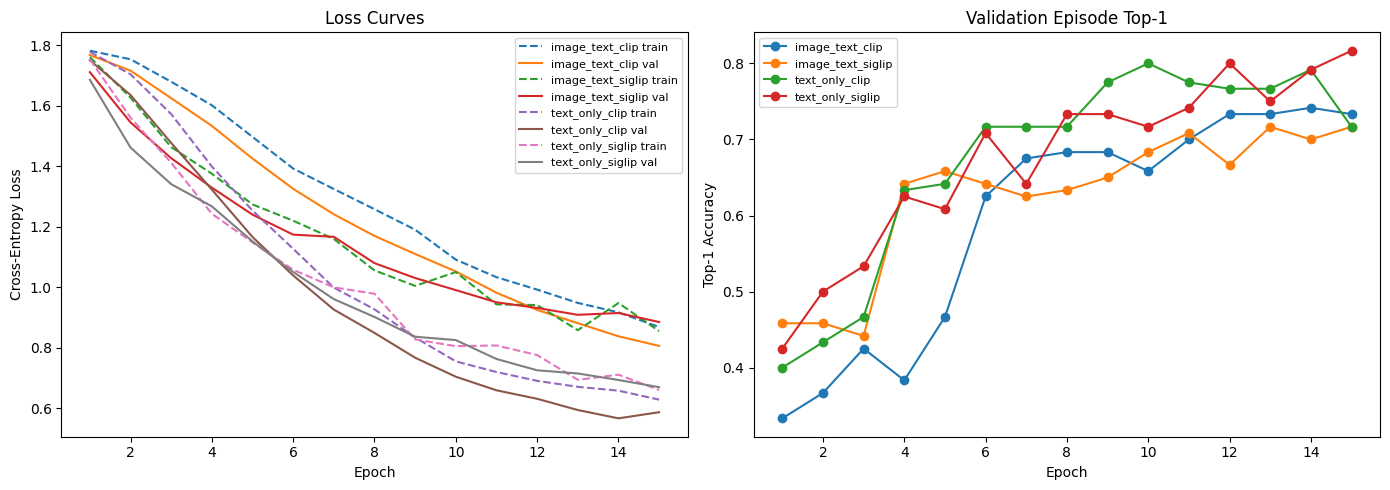

In [16]:
all_history_df = pd.concat([
    clip_text_history_df,
    clip_image_text_history_df,
    siglip_text_history_df,
    siglip_image_text_history_df,
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, hist in all_history_df.groupby('model'):
    axes[0].plot(hist['epoch'], hist['train_loss'], '--', label=f'{model_name} train')
    axes[0].plot(hist['epoch'], hist['val_loss'], label=f'{model_name} val')
    axes[1].plot(hist['epoch'], hist['val_episode_top1'], marker='o', label=model_name)

axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Validation Episode Top-1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Top-1 Accuracy')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Suggested Interpretation

- If `text_only_*` stays low, the semantic+spatial prompts are reducing language shortcut strength.
- If `image_text_*` exceeds `text_only_*`, the image is providing extra grounding signal.
- If SigLIP beats CLIP, that supports using SigLIP as the stronger frozen VLM backbone in the final report.
